# TextGraphicalizer: first WordNet ontology pass

Run the Laya-backed `TextGraphicalizer` on made-up paragraphs using the checked-in high-level WordNet ontology. The estimator owns the parameterized graph display function, so rendering can be reused outside this notebook.

> The first model load downloads the pinned Laya checkpoint into the Hugging Face cache.

## One-time setup

Use the existing `py312` kernel backed by the project venv. From the repository root, run these commands once in a terminal:

```bash
source ~/.venvs/py312/bin/activate
python -m pip install -e ".[notebook]"
python -m ipykernel install --user --name py312 --display-name "py312"
```

In [1]:
from pathlib import Path
import sys

assert (3, 10) <= sys.version_info[:2] <= (3, 12), (
    f"Use a Python 3.10–3.12 kernel; current interpreter is {sys.version}"
)
print(f"Using Python: {sys.executable}")

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "ontology.yaml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from textgraphicalizer import TextGraphicalizer

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 15, "font.size": 10})
ontology_path = ROOT / "ontology.yaml"
ontology_path

Using Python: /Users/f.costa/.venvs/py312/bin/python


PosixPath('/Users/f.costa/Code/TextGraphicalizer/ontology.yaml')

In [ ]:
extractor = TextGraphicalizer().load_model()

## Made-up paragraphs

In [ ]:
paragraphs = [
    ("Storm response", "After a heavy storm, the river flooded the village and forced the emergency organization to move residents to a nearby shelter."),
    ("Drought and harvest", "The research team published a report explaining that repeated drought reduced the harvest and changed the condition of the soil."),
    ("Robot workshop", "A university launched a program that taught students how to build a small robot from metal parts and use it in the laboratory."),
]

In [18]:
extractor.ontology = ontology_path
extractor.node_threshold = 0.35
extractor.edge_threshold = 0.7
extractor.connected = True
extractor.max_node_degree = 4
extractor.use_milp = True

In [19]:

graphs = []
for title, paragraph in paragraphs:
    graph = extractor.transform(paragraph)
    graphs.append((title, paragraph, graph))
    print(f"{title}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Storm response: 8 nodes, 11 edges
Drought and harvest: 5 nodes, 8 edges
Robot workshop: 8 nodes, 13 edges


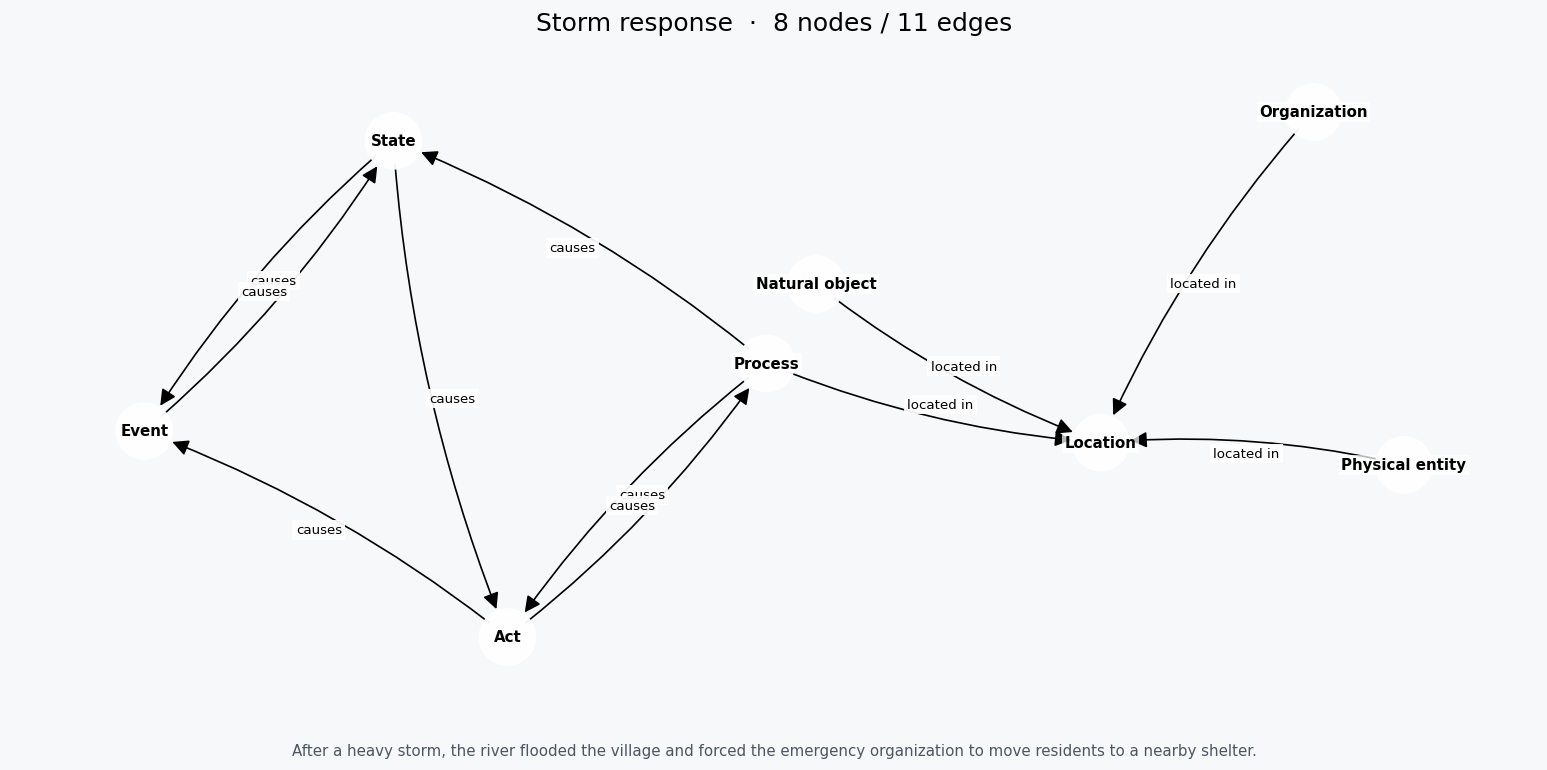

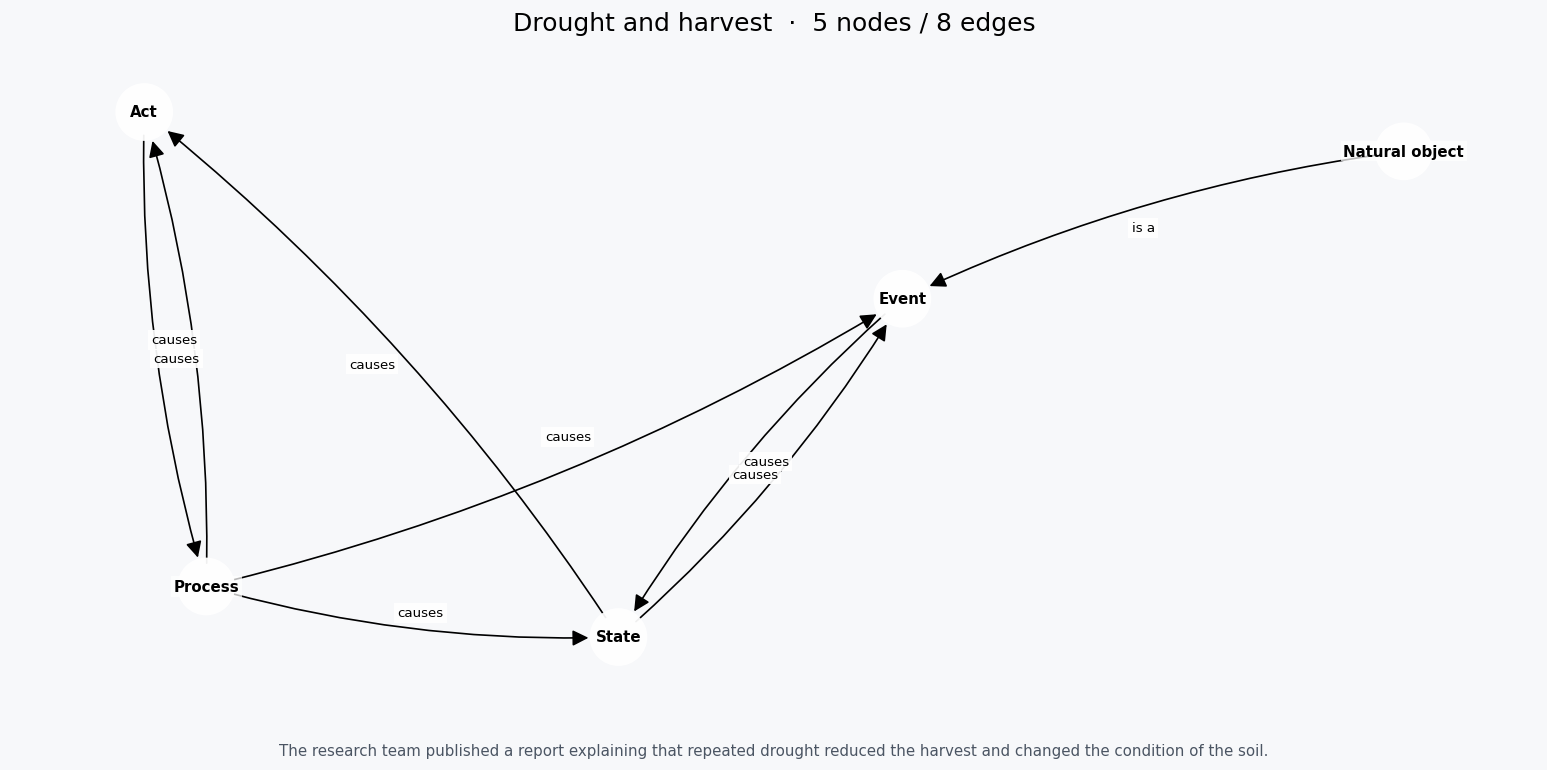

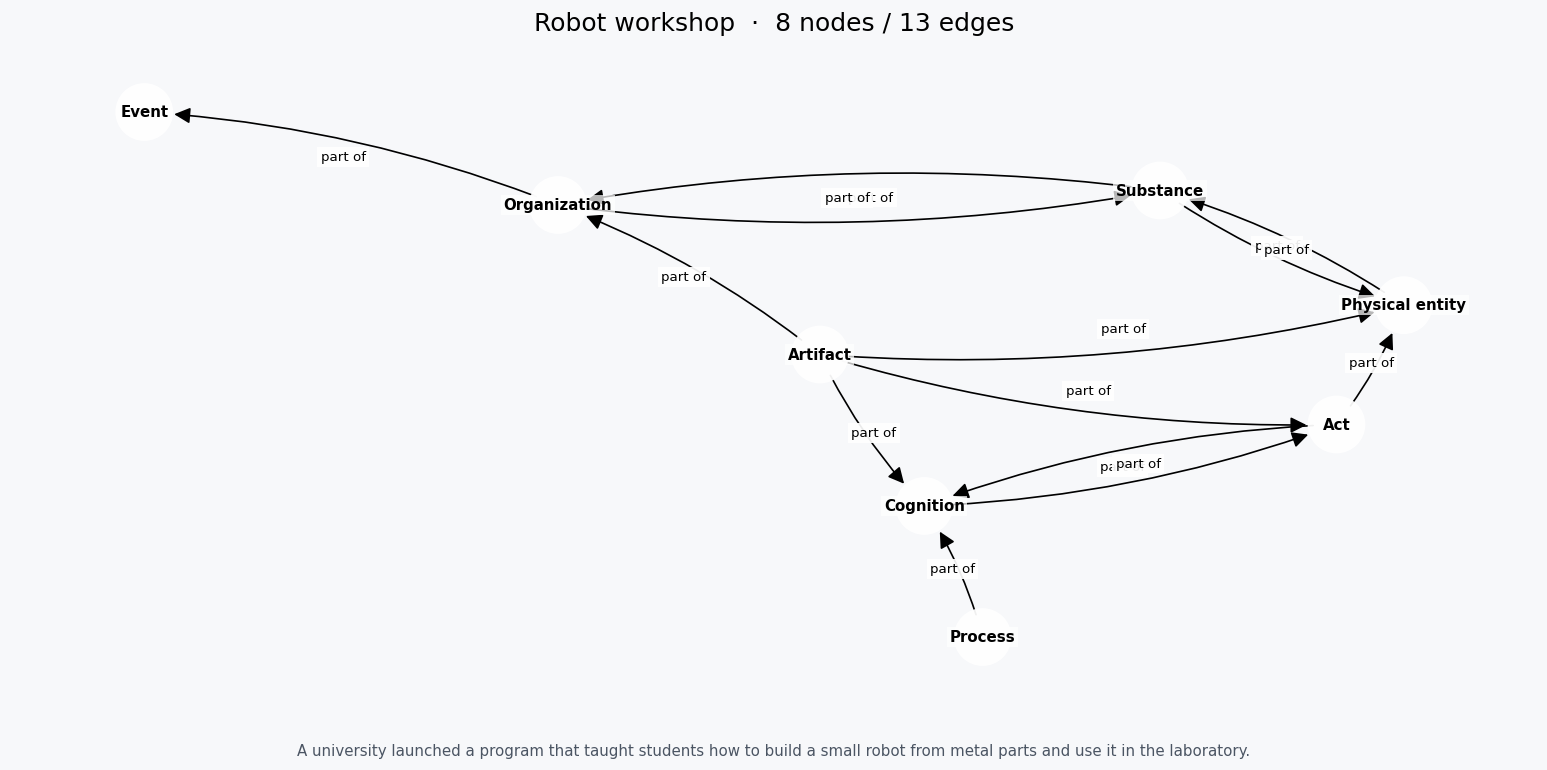

In [20]:
for title, paragraph, graph in graphs:
    extractor.display(graph, title=title, paragraph=paragraph)

## Inspect one graph as ordinary NetworkX data

In [21]:
title, paragraph, graph = graphs[2]
print("Nodes:")
display(list(graph.nodes(data=True)))
print("Edges:")
display(list(graph.edges(data=True)))
print("Graph metadata:")
display(graph.graph)

Nodes:


[('physical_entity',
  {'label': 'Physical entity', 'probability': 0.5251, 'confidence': 0.5251}),
 ('organization',
  {'label': 'Organization', 'probability': 0.3448, 'confidence': 0.6552}),
 ('artifact',
  {'label': 'Artifact', 'probability': 0.3462, 'confidence': 0.6538}),
 ('substance',
  {'label': 'Substance', 'probability': 0.7457, 'confidence': 0.7457}),
 ('event', {'label': 'Event', 'probability': 0.7658, 'confidence': 0.7658}),
 ('act', {'label': 'Act', 'probability': 0.6748, 'confidence': 0.6748}),
 ('process', {'label': 'Process', 'probability': 0.687, 'confidence': 0.687}),
 ('cognition',
  {'label': 'Cognition', 'probability': 0.7725, 'confidence': 0.7725})]

Edges:


[('physical_entity',
  'substance',
  {'label': 'part of',
   'probability': 0.7628,
   'existence_probability': 0.7628,
   'relation_probability': 0.4066,
   'confidence': 0.0532}),
 ('organization',
  'substance',
  {'label': 'part of',
   'probability': 0.7524,
   'existence_probability': 0.7524,
   'relation_probability': 0.3904,
   'confidence': 0.0445}),
 ('organization',
  'event',
  {'label': 'part of',
   'probability': 0.7017,
   'existence_probability': 0.7017,
   'relation_probability': 0.3323,
   'confidence': 0.0312}),
 ('artifact',
  'physical_entity',
  {'label': 'part of',
   'probability': 0.7681,
   'existence_probability': 0.7681,
   'relation_probability': 0.4131,
   'confidence': 0.0519}),
 ('artifact',
  'organization',
  {'label': 'part of',
   'probability': 0.7524,
   'existence_probability': 0.7524,
   'relation_probability': 0.3827,
   'confidence': 0.0409}),
 ('artifact',
  'act',
  {'label': 'part of',
   'probability': 0.774,
   'existence_probability': 0

Graph metadata:


{'ontology_version': 1,
 'model_id': 'convaiinnovations/laya',
 'model_revision': '7c76b622dfc5cac71b2dc1c29873efe2ce509a05',
 'node_threshold': 0.35,
 'edge_threshold': 0.7,
 'use_milp': True,
 'connected': True,
 'max_node_degree': 4,
 'solver': 'scipy.optimize.milp',
 'input_truncated': False}